<a href="https://colab.research.google.com/github/ankita6876/AURUM-Net/blob/main/AURUM_Net.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# AURUM-Net: Regime-Gated Uncertainty-Aware Gold Price Forecasting

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


df = pd.read_csv("Gold Price.csv")

df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date')
df.set_index('Date', inplace=True)

df.head()
df.tail()
df.info()



<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 3104 entries, 2014-01-01 to 2026-01-02
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Price   3104 non-null   int64  
 1   Open    3104 non-null   int64  
 2   High    3104 non-null   int64  
 3   Low     3104 non-null   int64  
 4   Volume  3104 non-null   int64  
 5   Chg%    3104 non-null   float64
dtypes: float64(1), int64(5)
memory usage: 169.8 KB


In [ ]:
print(df.columns)


Index(['Price', 'Open', 'High', 'Low', 'Volume', 'Chg%'], dtype='object')


In [ ]:
df.reset_index(inplace=True)
df.rename(columns={'index': 'Date'}, inplace=True)


In [ ]:
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
df = df.dropna(subset=['Date'])
df = df.sort_values('Date')
df.set_index('Date', inplace=True) # Set 'Date' as index after cleaning and sorting

In [ ]:
print(df.index.min())
print(df.index.max())

2014-01-01 00:00:00
2026-01-02 00:00:00


In [ ]:
# Rename for financial convention
df.rename(columns={'Price': 'Close'}, inplace=True)

# Convert Chg% to float (if not already)
df['Chg%'] = df['Chg%'].astype(float)

# This line was creating an artificial index, causing a date mismatch.
# Removed: df.index = pd.date_range(start='2000-01-01', periods=len(df), freq='D')

df.head()

,Close,Open,High,Low,Volume,Chg%
Date,,,,,,
2014-01-01,29542,29435,29598,29340,2930,0.25
2014-01-02,29975,29678,30050,29678,3140,1.47
2014-01-03,29727,30031,30125,29539,3050,-0.83
2014-01-04,29279,29279,29279,29279,0,-1.51
2014-01-06,29119,29300,29395,29051,24380,-0.55


#Feature Engineering (Regime-Sensitive)

In [ ]:
# Log returns
df['Log_Return'] = np.log(df['Close'] / df['Close'].shift(1))

# Volatility (rolling)
df['Volatility'] = df['Log_Return'].rolling(14).std()

# Technical indicators
df['MA_10'] = df['Close'].rolling(10).mean()
df['MA_30'] = df['Close'].rolling(30).mean()

# Price range pressure
df['HL_Range'] = df['High'] - df['Low']
df['OC_Change'] = df['Open'] - df['Close']

df.dropna(inplace=True)


In [ ]:
from sklearn.mixture import GaussianMixture

regime_features = df[['Log_Return', 'Volatility']].dropna()

gmm = GaussianMixture(n_components=3, covariance_type='full', random_state=42)
gmm_regime_labels = gmm.fit_predict(regime_features)

# Store GMM labels directly into df, aligning by index
df.loc[regime_features.index, 'GMM_Regime_Labels'] = gmm_regime_labels
# Fill NaNs that occur outside of regime_features.index (e.g., due to initial dropna) with -1, to be removed later.
df['GMM_Regime_Labels'] = df['GMM_Regime_Labels'].fillna(-1).astype(int)

probs = gmm.predict_proba(regime_features)

df.loc[regime_features.index, 'regime_low_vol'] = probs[:, 0]
df.loc[regime_features.index, 'regime_mid_vol'] = probs[:, 1]
df.loc[regime_features.index, 'regime_high_vol'] = probs[:, 2]

# VOLATILITY-AWARE TARGET

In [ ]:
# Log returns
df['Return'] = np.log(df['Close'] / df['Close'].shift(1))

# Rolling volatility (20-day window)
df['Volatility'] = df['Return'].rolling(window=20).std()

df.dropna(inplace=True)

#Market Regime Detection (NOVEL)

In [ ]:
from sklearn.cluster import KMeans

vol = df[['Volatility']]

# Market regime now uses 3 GMM components, not binary volatility threshold
# Ensure 'GMM_Regime_Labels' exists and is correctly populated from previous cell
df['Regime'] = df['GMM_Regime_Labels'] # Use the GMM labels (0, 1, 2, or -1 for initial NaNs)

# Label regimes (optional, update if necessary for visualization)
# The -1 will be dropped by subsequent dropna operations
df['Regime_Label'] = df['Regime'].map({0: 'Regime 0', 1: 'Regime 1', 2: 'Regime 2', -1: 'Unknown'})

In [ ]:
# Create the primary target (future Close price)
df['Target_Close'] = df['Close'].shift(-1)
# Create future volatility and regime targets
df['Target_Volatility'] = df['Volatility'].shift(-1)
df['Target_Regime'] = df['Regime'].shift(-1)

# Drop any rows where features or the new target are NaN
df.dropna(inplace=True)

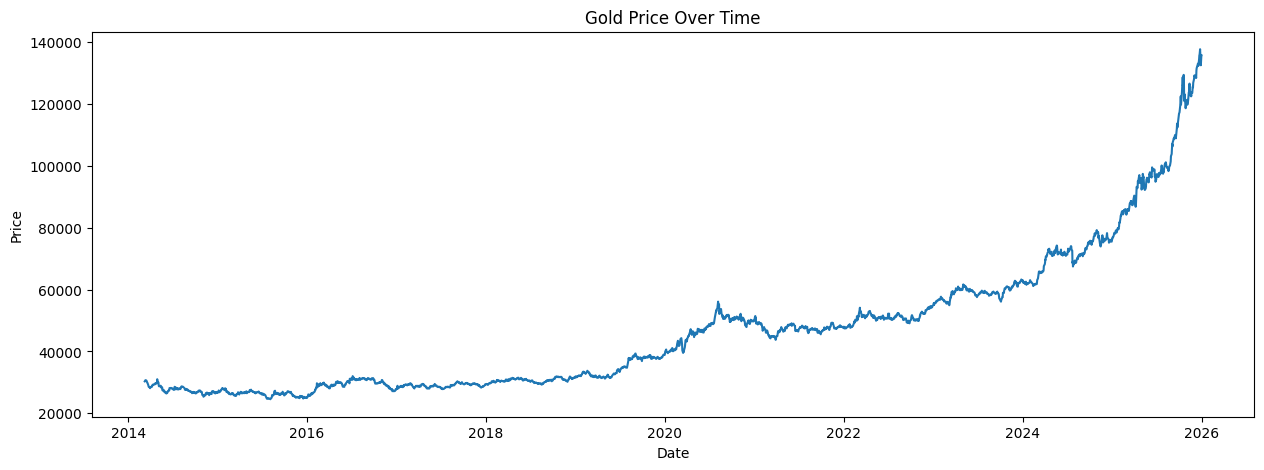

In [ ]:
plt.figure(figsize=(15,5))
plt.plot(df.index, df['Close'])
plt.title('Gold Price Over Time')
plt.xlabel('Date')
plt.ylabel('Price')
plt.show()

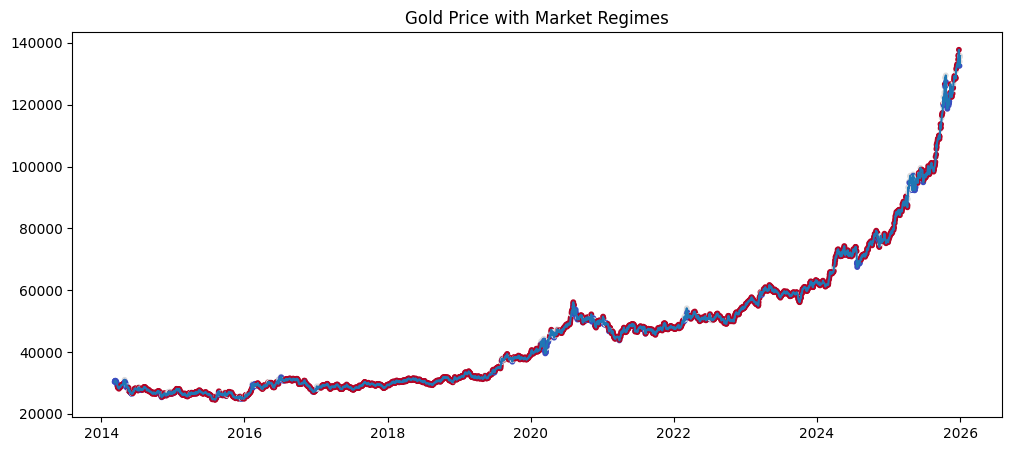

In [ ]:
plt.figure(figsize=(12,5))
plt.plot(df.index, df['Close'], label='Gold Price')
plt.scatter(df.index, df['Close'], c=df['Regime'], cmap='coolwarm', s=10)
plt.title("Gold Price with Market Regimes")
plt.show()




# Scaling + Sequence Creation



In [ ]:
from sklearn.preprocessing import MinMaxScaler
import numpy as np
from sklearn.model_selection import train_test_split # Import train_test_split
from tensorflow.keras.utils import to_categorical # NEW: Import to_categorical
import tensorflow as tf # Import TensorFlow

features = ['Close', 'Open', 'High', 'Low', 'Volume', 'Volatility', 'Regime']

# Define the target features
target_feature_price = 'Target_Close'
target_feature_volatility = 'Target_Volatility'
target_feature_regime = 'Target_Regime'

# Create separate scalers for features (X) and targets (y)
scaler_X = MinMaxScaler()
scaled_X = scaler_X.fit_transform(df[features])

scaler_y_price = MinMaxScaler()
scaled_y_price = scaler_y_price.fit_transform(df[[target_feature_price]])

scaler_y_volatility = MinMaxScaler()
scaled_y_volatility = scaler_y_volatility.fit_transform(df[[target_feature_volatility]])

# NEW: For regime, we will use integer labels directly from df['Target_Regime']
# and then one-hot encode them. No scaler needed for regime labels.
y_regime_labels_raw = df[target_feature_regime].values.flatten() # Get raw labels as 1D array

# Modified create_multi_resolution_windows function to take X and Y separately
def create_multi_resolution_windows(X_data, y_price_data, y_vol_data, y_reg_data_labels_raw, short=7, mid=30, long=120):
    Xs, Xm, Xl, y_price_seq, y_vol_seq, y_reg_seq_labels_raw = [], [], [], [], [], []

    # Iterate through the data to create windows and corresponding targets
    # The target for a window ending at `i-1` is at `i`.
    # So the loop should go from `long` up to `len(X_data)`
    for i in range(long, len(X_data)):
        Xs.append(X_data[i-short:i]) # Window for short term features
        Xm.append(X_data[i-mid:i])   # Window for mid term features
        Xl.append(X_data[i-long:i])  # Window for long term features

        # Targets corresponding to the end of the window (i.e., predicting for index 'i')
        y_price_seq.append(y_price_data[i])
        y_vol_seq.append(y_vol_data[i])
        y_reg_seq_labels_raw.append(y_reg_data_labels_raw[i]) # Append raw integer labels

    return (
        np.array(Xs),
        np.array(Xm),
        np.array(Xl),
        np.array(y_price_seq),
        np.array(y_vol_seq),
        np.array(y_reg_seq_labels_raw) # Return raw integer labels
    )

# Call the modified function to get all sequences
Xs, Xm, Xl, y_price, y_vol, y_reg_labels_int = create_multi_resolution_windows(
    scaled_X, scaled_y_price, scaled_y_volatility, y_regime_labels_raw, # Pass 1D array
    short=7, mid=30, long=120
)

# NEW: One-hot encode the regime labels
# Assuming 3 classes (0, 1, 2) based on GMM_Regime_Labels
y_reg = to_categorical(y_reg_labels_int, num_classes=3)

# Perform train-test split for each resolution of features and all targets
# Use one split index for all data to maintain chronological order
split_index = int(len(Xs) * 0.8) # Assuming all X and y sequences have the same length

# Convert all numpy arrays to tf.Tensor with float32 dtype explicitly
X_train_s, X_val_s = tf.convert_to_tensor(Xs[:split_index], dtype=tf.float32), tf.convert_to_tensor(Xs[split_index:], dtype=tf.float32)
X_train_m, X_val_m = tf.convert_to_tensor(Xm[:split_index], dtype=tf.float32), tf.convert_to_tensor(Xm[split_index:], dtype=tf.float32)
X_train_l, X_val_l = tf.convert_to_tensor(Xl[:split_index], dtype=tf.float32), tf.convert_to_tensor(Xl[split_index:], dtype=tf.float32)

y_price_train, y_price_val = tf.convert_to_tensor(y_price[:split_index], dtype=tf.float32), tf.convert_to_tensor(y_price[split_index:], dtype=tf.float32)
y_vol_train, y_vol_val = tf.convert_to_tensor(y_vol[:split_index], dtype=tf.float32), tf.convert_to_tensor(y_vol[split_index:], dtype=tf.float32)
y_reg_train, y_reg_val = tf.convert_to_tensor(y_reg[:split_index], dtype=tf.float32), tf.convert_to_tensor(y_reg[split_index:], dtype=tf.float32)

# Multi-head Attention LSTM (Regime-Gated Attention)

In [ ]:
from tensorflow.keras.layers import Input, LSTM, Dense, Concatenate, Attention
from tensorflow.keras.models import Model
import keras.ops as ops # Import keras.ops

input_s = Input(shape=(X_train_s.shape[1], X_train_s.shape[2]))
input_m = Input(shape=(X_train_m.shape[1], X_train_m.shape[2]))
input_l = Input(shape=(X_train_l.shape[1], X_train_l.shape[2]))

enc_s = LSTM(32, return_sequences=True)(input_s)
enc_m = LSTM(32, return_sequences=True)(input_m)
enc_l = LSTM(32, return_sequences=True)(input_l)

from tensorflow.keras.layers import Multiply, Softmax

# Regime gate (learned from long-term context)
regime_gate = Dense(3, activation='softmax', name='regime_gate')(enc_l[:, -1, :])

# Create attention heads
attn_s = Attention()([enc_s, enc_s])[:, -1, :]
attn_m = Attention()([enc_m, enc_m])[:, -1, :]
attn_l = enc_l[:, -1, :]

# Stack attention heads using keras.ops
attn_stack = ops.stack([attn_s, attn_m, attn_l], axis=1)

# Apply regime gate using keras.ops
gate_expanded = ops.expand_dims(regime_gate, axis=-1)
gated_context = ops.sum(attn_stack * gate_expanded, axis=1)


shared = Dense(64, activation='relu')(gated_context)

# Predict price distribution instead of point estimate
from tensorflow.keras.layers import Lambda

base = Dense(1)(shared)

delta1 = Dense(1, activation='softplus')(shared)
delta2 = Dense(1, activation='softplus')(shared)

price_q10 = Lambda(lambda x: x[0] - x[1] - x[2], name='price_q10')([base, delta1, delta2])
price_q50 = Lambda(lambda x: x[0], name='price_q50')([base])
price_q90 = Lambda(lambda x: x[0] + x[1] + x[2], name='price_q90')([base, delta1, delta2])


vol_out = Dense(1, name='volatility')(shared)
regime_out = Dense(3, activation='softmax', name='regime')(shared)

model = Model(
    inputs=[input_s, input_m, input_l],
    outputs=[price_q10, price_q50, price_q90, vol_out, regime_out]
)

def quantile_loss(q):
    def loss(y_true, y_pred):
        e = y_true - y_pred
        return tf.reduce_mean(tf.maximum(q * e, (q - 1) * e))
    return loss


model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss={
        'price_q10': quantile_loss(0.10),
        'price_q50': quantile_loss(0.50),
        'price_q90': quantile_loss(0.90),
        'volatility': 'mse',
        'regime': 'categorical_crossentropy' # Changed from sparse_categorical_crossentropy
    },
    metrics={
        'price_q50': ['mae'],
        'regime': ['accuracy']
    }
)


model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_6       │ (None, 7, 7)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_7       │ (None, 30, 7)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_8       │ (None, 120, 7)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_6 (LSTM)       │ (None, 7, 32)     │      5,120 │ input_layer_6[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_7 (LSTM)       │ (None, 30, 32)    │      5,120 │ input_layer_7[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_8 (LSTM)       │ (None, 120, 32)   │      5,120 │ input_layer_8[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention_4         │ (None, 7, 32)     │          0 │ lstm_6[0][0],     │
│ (Attention)         │                   │            │ lstm_6[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention_5         │ (None, 30, 32)    │          0 │ lstm_7[0][0],     │
│ (Attention)         │                   │            │ lstm_7[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_8          │ (None, 32)        │          0 │ lstm_8[0][0]      │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_9          │ (None, 32)        │          0 │ attention_4[0][0] │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_10         │ (None, 32)        │          0 │ attention_5[0][0] │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_11         │ (None, 32)        │          0 │ lstm_8[0][0]      │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ regime_gate (Dense) │ (None, 3)         │         99 │ get_item_8[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack_2 (Stack)     │ (None, 3, 32)     │          0 │ get_item_9[0][0], │
│                     │                   │            │ get_item_10[0][0… │
│                     │                   │            │ get_item_11[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expand_dims_2       │ (None, 3, 1)      │          0 │ regime_gate[0][0] │
│ (ExpandDims)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply_2          │ (None, 3, 32)     │          0 │ stack_2[0][0],    │
│ (Multiply)          │                   │            │ expand_dims_2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sum_2 (Sum)         │ (None, 32)        │          0 │ multiply_2[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 64)        │      2,112 │ sum_2[0][0]       │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 18,026 (70.41 KB)

 Trainable params: 18,026 (70.41 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.fit(
    [X_train_s, X_train_m, X_train_l],
    {
        'price_q10': y_price_train,
        'price_q50': y_price_train,
        'price_q90': y_price_train,
        'volatility': y_vol_train,
        'regime': y_reg_train
    },
    validation_data=(
        [X_val_s, X_val_m, X_val_l],
        {
            'price_q10': y_price_val,
            'price_q50': y_price_val,
            'price_q90': y_price_val,
            'volatility': y_vol_val,
            'regime': y_reg_val
        }
    ),
    epochs=50,
    batch_size=32
)


Epoch 1/50
74/74 ━━━━━━━━━━━━━━━━━━━━ 14s 74ms/step - loss: 1.0545 - price_q10_loss: 0.1166 - price_q50_loss: 0.0431 - price_q50_mae: 0.0863 - price_q90_loss: 0.1034 - regime_accuracy: 0.8414 - regime_loss: 0.7553 - volatility_loss: 0.0362 - val_loss: 0.7056 - val_price_q10_loss: 0.0202 - val_price_q50_loss: 0.0316 - val_price_q50_mae: 0.0574 - val_price_q90_loss: 0.0121 - val_regime_accuracy: 0.8109 - val_regime_loss: 0.6344 - val_volatility_loss: 0.0376
Epoch 2/50
74/74 ━━━━━━━━━━━━━━━━━━━━ 6s 77ms/step - loss: 0.4953 - price_q10_loss: 0.0101 - price_q50_loss: 0.0080 - price_q50_mae: 0.0161 - price_q90_loss: 0.0102 - regime_accuracy: 0.8668 - regime_loss: 0.4546 - volatility_loss: 0.0124 - val_loss: 0.5724 - val_price_q10_loss: 0.0162 - val_price_q50_loss: 0.0349 - val_price_q50_mae: 0.0652 - val_price_q90_loss: 0.0125 - val_regime_accuracy: 0.8109 - val_regime_loss: 0.5222 - val_volatility_loss: 0.0179
Epoch 3/50
74/74 ━━━━━━━━━━━━━━━━━━━━ 5s 61ms/step - loss: 0.3993 - price_q10_los

In [ ]:
pred_q10, pred_q50, pred_q90, pred_vol, pred_reg = model.predict(
    [X_val_s, X_val_m, X_val_l]
)


19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 65ms/step


In [ ]:
# Convert tensors to numpy
y_price_val_np = y_price_val.numpy()
y_vol_val_np   = y_vol_val.numpy()
y_reg_val_np   = y_reg_val.numpy()

pred_price_np = pred_q50 # Corrected: 'pred_price' was not defined, should be pred_q50
pred_vol_np   = pred_vol
pred_reg_np   = pred_reg

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

price_mae = mean_absolute_error(y_price_val_np, pred_price_np)
price_rmse = np.sqrt(mean_squared_error(y_price_val_np, pred_price_np))

print(f"Price MAE  : {price_mae:.4f}")
print(f"Price RMSE : {price_rmse:.4f}")


Price MAE  : 0.0603
Price RMSE : 0.0984


In [ ]:
vol_mae = mean_absolute_error(y_vol_val_np, pred_vol_np)
print(f"Volatility MAE : {vol_mae:.4f}")


Volatility MAE : 0.0485


In [ ]:
from sklearn.metrics import accuracy_score

true_regime = np.argmax(y_reg_val_np, axis=1)
pred_regime = np.argmax(pred_reg_np, axis=1)

regime_acc = accuracy_score(true_regime, pred_regime)
print(f"Regime Classification Accuracy: {regime_acc:.4f}")


Regime Classification Accuracy: 0.8722


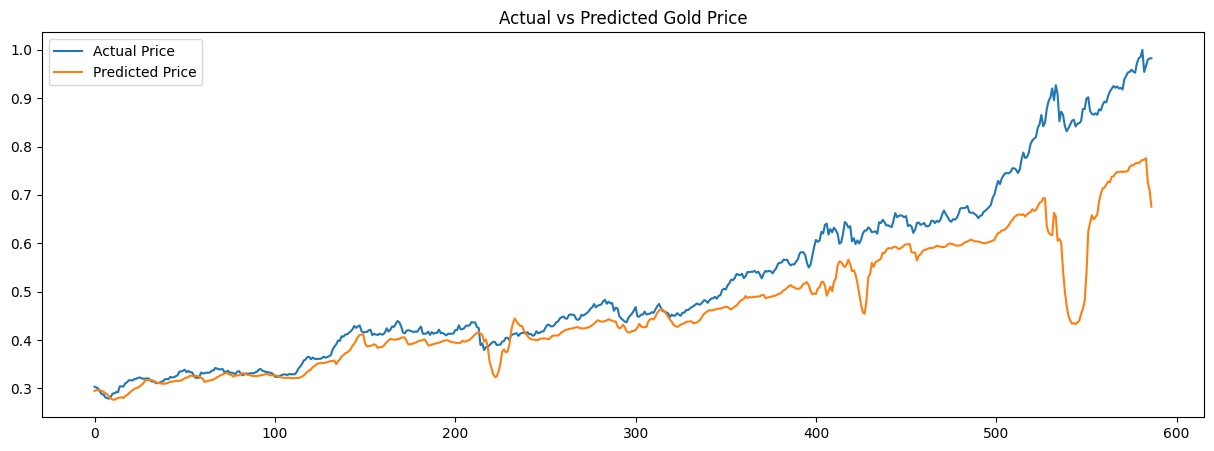

In [ ]:
plt.figure(figsize=(15,5))
plt.plot(y_price_val, label='Actual Price')
plt.plot(pred_price_np, label='Predicted Price')
plt.title('Actual vs Predicted Gold Price')
plt.legend()
plt.show()

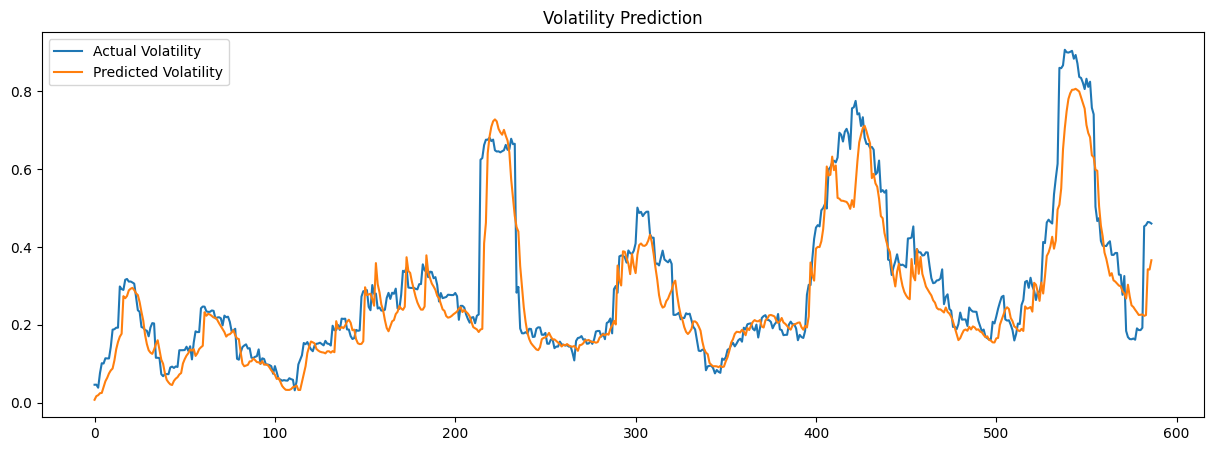

In [ ]:
plt.figure(figsize=(15,5))
plt.plot(y_vol_val, label='Actual Volatility')
plt.plot(pred_vol, label='Predicted Volatility')
plt.title('Volatility Prediction')
plt.legend()
plt.show()


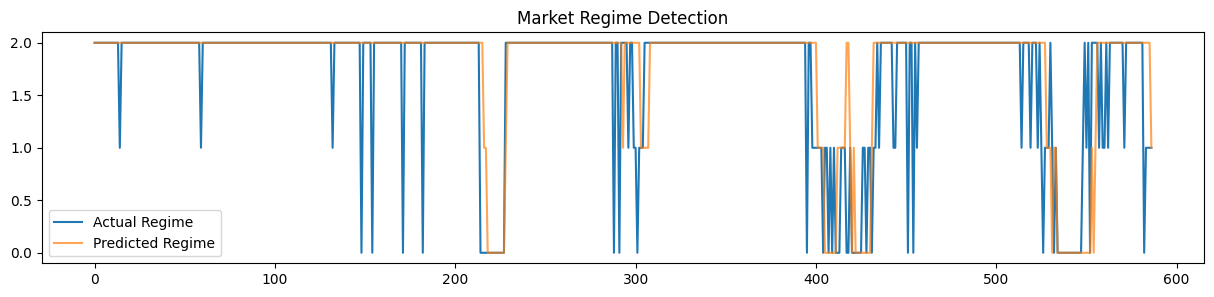

In [ ]:
plt.figure(figsize=(15,3))
plt.plot(true_regime, label='Actual Regime')
plt.plot(pred_regime, alpha=0.7, label='Predicted Regime')
plt.title('Market Regime Detection')
plt.legend()
plt.show()


/tmp/ipython-input-2451864574.py:6: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(


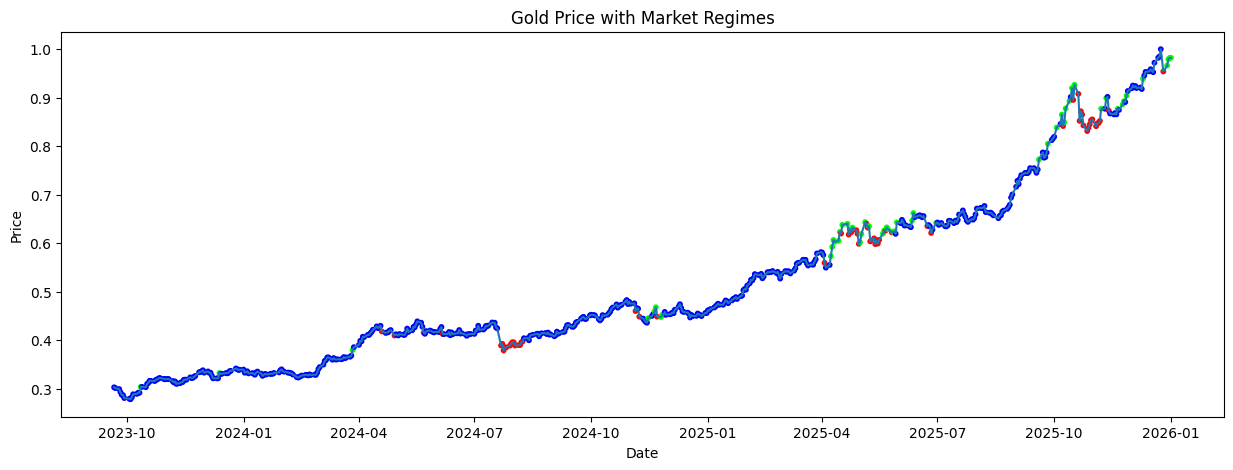

In [ ]:
val_dates = df.index[-len(y_price_val):]

plt.figure(figsize=(15,5))
plt.plot(val_dates, y_price_val, label='Price')

plt.scatter(
    val_dates,
    y_price_val,
    c=y_reg_val,
    cmap='coolwarm',
    s=10,
    label='Regime'
)

plt.title('Gold Price with Market Regimes')
plt.xlabel('Date')
plt.ylabel('Price')
plt.show()

In [ ]:
# Coverage probability
coverage = np.mean(
    (y_price_val_np >= pred_q10) & (y_price_val_np <= pred_q90)
)

print(f"80% Interval Coverage: {coverage:.3f}")

80% Interval Coverage: 0.181


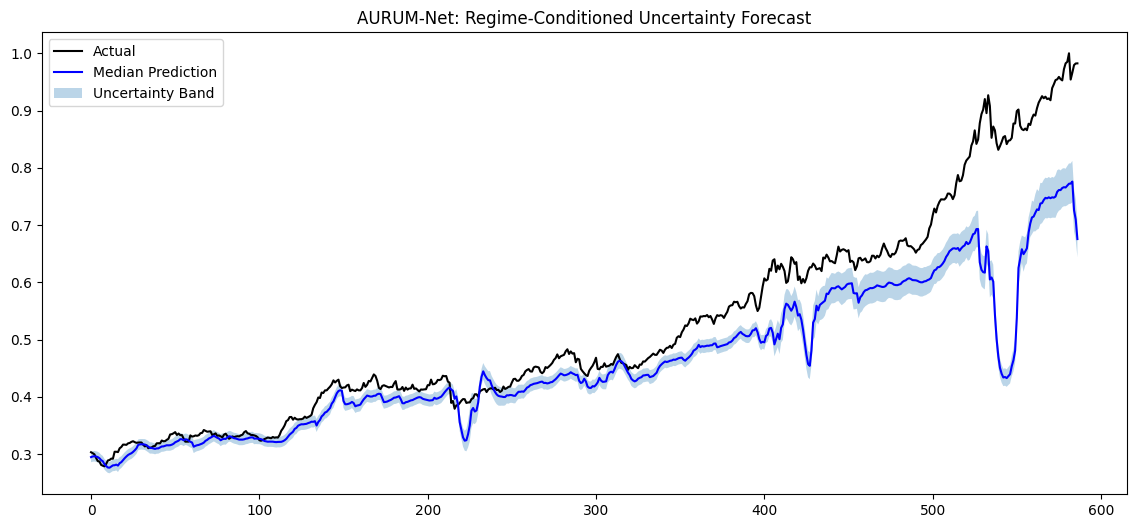

In [ ]:
plt.figure(figsize=(14,6))
plt.plot(y_price_val_np, label='Actual', color='black')
plt.plot(pred_q50, label='Median Prediction', color='blue')
plt.fill_between(
    range(len(pred_q50)),
    pred_q10.flatten(),
    pred_q90.flatten(),
    alpha=0.3,
    label='Uncertainty Band'
)
plt.legend()
plt.title("AURUM-Net: Regime-Conditioned Uncertainty Forecast")
plt.show()

In [ ]:
val_dates = df.index[-len(y_price_val_np):]

recent_mask = val_dates >= pd.Timestamp('2022-01-01')

recent_mae = mean_absolute_error(
    y_price_val_np[recent_mask],
    pred_price_np[recent_mask]
)

print("Recent Period MAE:", recent_mae)


Recent Period MAE: 0.060334865003824234


# ATTENTION-BASED LSTM

# QUANTILE REGRESSION

In [ ]:
def quantile_loss(q):
    def loss(y_true, y_pred):
        e = y_true - y_pred
        return tf.reduce_mean(tf.maximum(q*e, (q-1)*e))
    return loss


In [ ]:
model.compile(
    optimizer='adam',
    loss={
        'subtract_1': quantile_loss(0.1),
        'dense_2': quantile_loss(0.5),
        'add_1': quantile_loss(0.9),
        'volatility': 'mse',
        'regime': 'categorical_crossentropy'
    },
    loss_weights={
        'subtract_1': 0.3,
        'dense_2': 0.3,
        'add_1': 0.3,
        'volatility': 0.05,
        'regime': 0.05
    }

)

In [ ]:
# Interval coverage
lower = pred_q10
upper = pred_q90
true = y_price_val_np

picp = np.mean((true >= lower) & (true <= upper))
mpiw = np.mean(upper - lower)

print(f"PICP (coverage): {picp:.3f}")
print(f"MPIW (interval width): {mpiw:.3f}")


PICP (coverage): 0.181
MPIW (interval width): 0.033


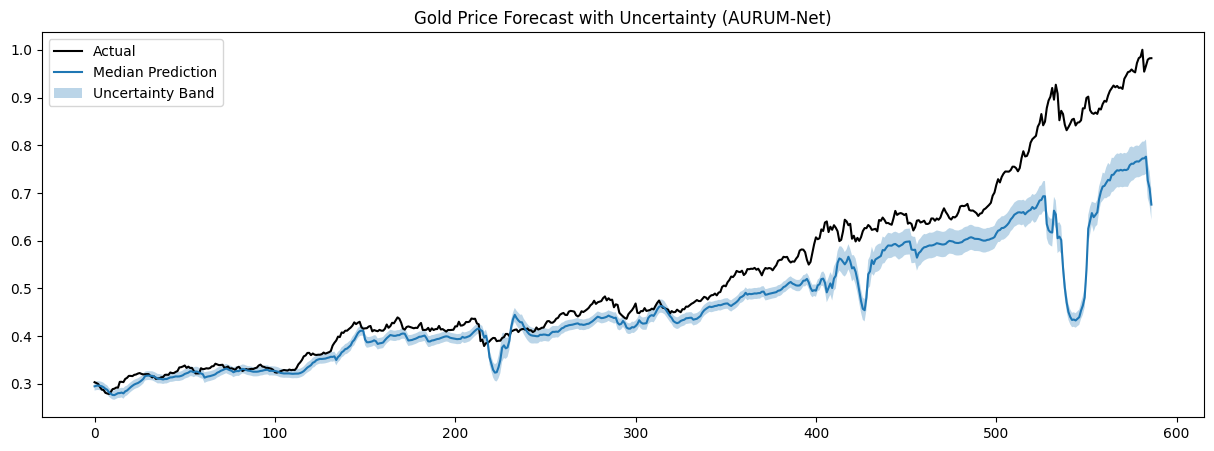

In [ ]:
plt.figure(figsize=(15,5))
plt.plot(true, label='Actual', color='black')
plt.plot(pred_q50, label='Median Prediction')
plt.fill_between(
    range(len(true)),
    pred_q10.flatten(),
    pred_q90.flatten(),
    alpha=0.3,
    label='Uncertainty Band'
)
plt.legend()
plt.title('Gold Price Forecast with Uncertainty (AURUM-Net)')
plt.show()


In [ ]:
direction_true = np.sign(y_price_val_np[1:] - y_price_val_np[:-1])
direction_pred = np.sign(pred_q50[1:] - pred_q50[:-1])

directional_accuracy = np.mean(direction_true == direction_pred)
print("Directional Accuracy:", directional_accuracy)

Directional Accuracy: 0.5290102389078498


In [ ]:
coverage_80 = np.mean(
    (y_price_val_np >= pred_q10) & (y_price_val_np <= pred_q90)
)
print("80% Prediction Interval Coverage:", coverage_80)


80% Prediction Interval Coverage: 0.18057921635434412


In [ ]:
for r in range(3):
    # pred_regime is already a 1D array of argmax from LpjQePWC9916
    idx = (pred_regime == r)
    if idx.sum() > 20:
        print(f"Regime {r} RMSE:",
              np.sqrt(mean_squared_error(y_price_val_np[idx], pred_q50[idx])))

Regime 0 RMSE: 0.24571297721335175
Regime 1 RMSE: 0.1443648282303226
Regime 2 RMSE: 0.06540532156617493
